### #1 데이터 준비 및 탐색

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

from matplotlib import font_manager

for _f in ['Malgun Gothic', 'AppleGothic', 'NanumGothic']:
    if _f in {f.name for f in font_manager.fontManager.ttflist}:
        plt.rcParams['font.family'] = _f
        break
else:
    print('폰트 없음')

plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv('nyc_citibike.csv') 

print("데이터 크기:", df.shape)

display(df.head())

데이터 크기: (72035, 18)


,start_date,end_date,start_hour,end_hour,trip_duration,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,usertype,birth_year,gender,day_since_register
0,2018-05-01,2018-05-01,4,4,390,3002,South End Ave & Liberty St,40.711512,-74.015756,79,Franklin St & W Broadway,40.719116,-74.006667,21105,Subscriber,1945,male,36
1,2018-05-01,2018-05-01,1,1,854,3611,Vernon Blvd & 47 Rd,40.744907,-73.953457,3572,34 Ave & 38 St,40.756913,-73.921631,32219,Subscriber,1998,male,29
2,2018-05-01,2018-05-01,4,4,526,515,W 43 St & 10 Ave,40.760094,-73.994618,388,W 26 St & 10 Ave,40.749718,-74.002950,33433,Subscriber,1954,male,55
3,2018-05-01,2018-05-01,3,3,885,3641,Broadway & W 25 St,40.742869,-73.989186,336,Sullivan St & Washington Sq,40.730477,-73.999061,32028,Subscriber,1963,male,32
4,2018-05-01,2018-05-01,1,1,324,3440,Fulton St & Adams St,40.692418,-73.989495,3308,Kane St & Clinton St,40.686176,-73.996453,26425,Subscriber,1965,male,34


In [30]:
df.describe().round(2)

,start_hour,end_hour,trip_duration,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bike_id,birth_year,day_since_register
count,72035.00,72035.00,72035.00,72035.00,72035.00,72035.00,72035.00,72035.00,72035.00,72035.00,72035.00,72035.00
mean,14.18,14.37,1046.75,1535.68,40.74,-73.98,1537.18,40.74,-73.98,26139.74,1977.99,30.47
std,4.81,4.85,8139.70,1418.09,0.03,0.02,1420.20,0.03,0.02,5793.54,11.87,17.34
min,0.00,0.00,61.00,72.00,40.65,-74.03,72.00,40.65,-74.04,14529.00,1885.00,1.00
25%,10.00,10.00,398.00,382.00,40.72,-74.00,382.00,40.72,-74.00,20533.00,1969.00,15.00
50%,15.00,15.00,681.00,504.00,40.74,-73.99,503.00,40.74,-73.99,27840.00,1980.00,30.00
75%,18.00,18.00,1201.00,3223.00,40.76,-73.97,3224.00,40.76,-73.97,30995.00,1988.00,46.00
max,23.00,23.00,1344462.00,3680.00,40.81,-73.91,3680.00,40.81,-73.91,33671.00,2002.00,60.00


In [21]:
print("결측치 개수:", df.isnull().sum())

print("데이터 타입:", df.dtypes)

결측치 개수: start_date                 0
end_date                   0
start_hour                 0
end_hour                   0
trip_duration              0
start_station_id           0
start_station_name         0
start_station_latitude     0
start_station_longitude    0
end_station_id             0
end_station_name           0
end_station_latitude       0
end_station_longitude      0
bike_id                    0
usertype                   0
birth_year                 0
gender                     0
day_since_register         0
dtype: int64
데이터 타입: start_date                     str
end_date                       str
start_hour                   int64
end_hour                     int64
trip_duration                int64
start_station_id             int64
start_station_name             str
start_station_latitude     float64
start_station_longitude    float64
end_station_id               int64
end_station_name               str
end_station_latitude       float64
end_station_longitude      fl

In [31]:
for c in df.columns:
    n = df[c].nunique()
    kind = '연속형 가능성' if n > 100 else '범주형 가능성'
    print(f'{c:<26} dtype={str(df[c].dtype):<8} 고유값 {n:>6}개   {kind}')

start_date                 dtype=str      고유값      1개   범주형 가능성
end_date                   dtype=str      고유값      9개   범주형 가능성
start_hour                 dtype=int64    고유값     24개   범주형 가능성
end_hour                   dtype=int64    고유값     24개   범주형 가능성
trip_duration              dtype=int64    고유값   4042개   연속형 가능성
start_station_id           dtype=int64    고유값    749개   연속형 가능성
start_station_name         dtype=str      고유값    749개   연속형 가능성
start_station_latitude     dtype=float64  고유값    749개   연속형 가능성
start_station_longitude    dtype=float64  고유값    749개   연속형 가능성
end_station_id             dtype=int64    고유값    752개   연속형 가능성
end_station_name           dtype=str      고유값    752개   연속형 가능성
end_station_latitude       dtype=float64  고유값    752개   연속형 가능성
end_station_longitude      dtype=float64  고유값    752개   연속형 가능성
bike_id                    dtype=int64    고유값  10147개   연속형 가능성
usertype                   dtype=str      고유값      2개   범주형 가능성
birth_year                 dtype=int64  

### 변수 구분

| 분석 카테고리 | 변수명 | 데이터 성격 및 분류 |
| :--- | :--- | :--- |
| **시간 흐름** | `start_date`, `end_date` | 날짜형 |
| | `start_hour`, `end_hour` | 이산형/범주형 |
| | `trip_duration` | 연속형 수치 데이터 |
| 공간/위치 | `start_station_id`, `start_station_name` | 명목형/범주형 |
| | `start_station_latitude`, `start_station_longitude`| 연속형 |
| | `end_station_*` | 위 시작 지점의 데이터 특성과 동일 |
| 자전거 정보 | `bike_id` | 단순 고유 식별자 |
| 탑승자 정보 | `usertype` | 범주형-이진 |
| | `gender` | 범주형-명목 |
| | `birth_year` | 수치형 |
| | `day_since_register` | 수치형 |

### #2 단일 변수 분석

trip_duration 기초 통계량: count    7.203500e+04
mean     1.046751e+03
std      8.139700e+03
min      6.100000e+01
25%      3.980000e+02
50%      6.810000e+02
75%      1.201000e+03
max      1.344462e+06
Name: trip_duration, dtype: float64
평균 주행 시간: 1046.75
중앙값 주행 시간: 681.00


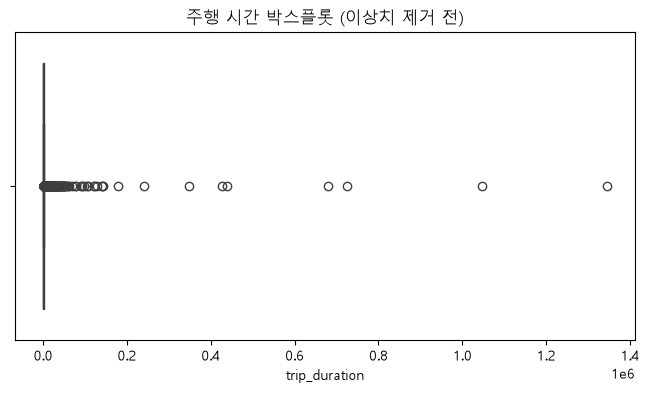

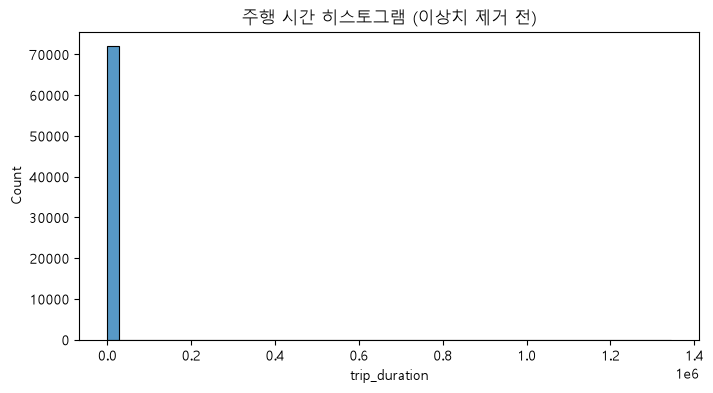

In [22]:
print("trip_duration 기초 통계량:", df['trip_duration'].describe())

mean_duration = df['trip_duration'].mean()
median_duration = df['trip_duration'].median()
print(f"평균 주행 시간: {mean_duration:.2f}")
print(f"중앙값 주행 시간: {median_duration:.2f}")

plt.figure(figsize=(8, 4))
sns.boxplot(x=df['trip_duration'])
plt.title('주행 시간 박스플롯 (이상치 제거 전)')
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(df['trip_duration'], bins=50)
plt.title('주행 시간 히스토그램 (이상치 제거 전)')
plt.show()

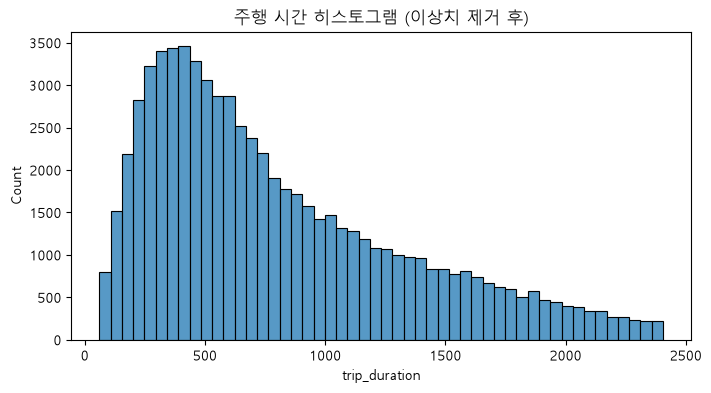

In [32]:
Q1 = df['trip_duration'].quantile(0.25)
Q3 = df['trip_duration'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_filtered = df[(df['trip_duration'] >= lower_bound) & (df['trip_duration'] <= upper_bound)]

plt.figure(figsize=(8, 4))
sns.histplot(df_filtered['trip_duration'], bins=50)
plt.title('주행 시간 히스토그램 (이상치 제거 후)')
plt.show()

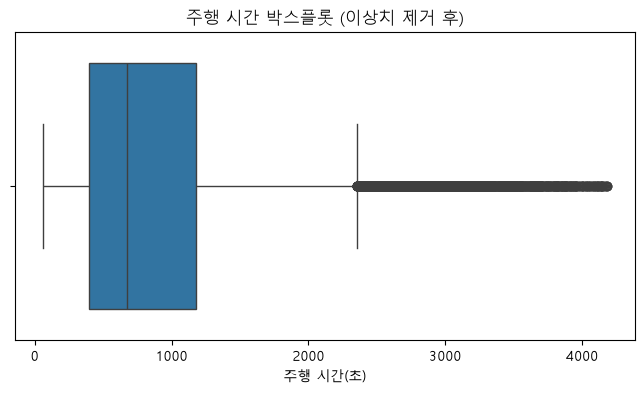

In [38]:
upper_bound = df['trip_duration'].quantile(0.99)

df_filtered = df[df['trip_duration'] <= upper_bound]

plt.figure(figsize=(8, 4))
sns.boxplot(x=df_filtered['trip_duration'])
plt.title('주행 시간 박스플롯 (이상치 제거 후)')
plt.xlabel('주행 시간(초)')
plt.show()

### 해석 - trip_duration
평균 왜곡: 대다수는 10~20분 내외로 짧게 이용하지만, 소수의 비정상적으로 긴 대여 기록 때문에 평균이 중앙값보다 1.5배 가량 높게 나타납니다.  

극단값의 원인: 최댓값이 무려 2만 분을 넘는 것을 볼 때, 이는 실제 주행이라기보다 반납 누락, 자전거 분실, 시스템 오류일 확률이 높습니다.  

분석 방향: 꼬리가 너무 길어 대다수 시민들의 실제 이용 패턴을 확인하기 아예 불가능하므로, 이 이상치를 과감히 잘라낸 후 다시 분석해야 합니다.
### 해석 - trip_duration 이상치 제거
현실적인 주행 패턴: 비정상적으로 긴 대여 기록을 제외한 히스토그램과 박스플롯을 보면, 전체 이용자의 대다수가 5분에서 20분 내외의 짧은 시간 동안만 자전거를 이용한다는 사실을 알 수 있습니다. 이는 뉴욕 시티바이크가 장시간 레저용으로 쓰이기보다는, 지하철역에서 직장이나 학교까지 이동하는 단거리의 통근 수단으로 활발히 쓰이고 있음을 보여줍니다.

이상치의 의미 유추: 몇 시간에서 심지어 며칠씩 대여한 것으로 기록된 비정상적인 데이터들은 실제 주행이라기보다는 반납 시 결착 오류, 자전거 분실, 혹은 정기 구독자가 아닌 일회성 사용자들의 시스템 이용 미숙으로 인해 요금이 계속 과금된 케이스일 확률이 높습니다.

분석의 안정성 확보: 소수의 극단값 때문에 원래 데이터의 평균이 실제 시민들의 이용 시간보다 과도하게 높게 나타나는 왜곡 현상이 있었습니다. 분석 목적에 맞게 상위 극단값을 절삭함으로써 전체적인 데이터의 흐름을 왜곡 없이 정확하게 파악할 수 있게 되었습니다.

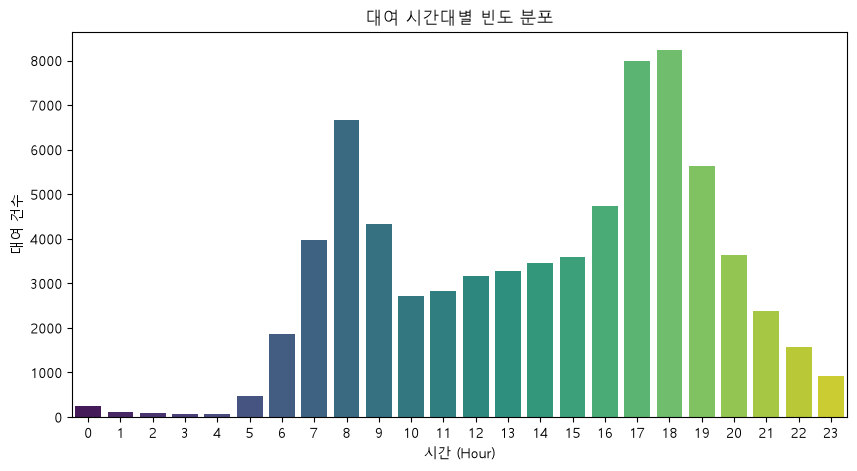

In [24]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='start_hour', palette='viridis')
plt.title('대여 시간대별 빈도 분포')
plt.xlabel('시간 (Hour)')
plt.ylabel('대여 건수')
plt.show()

### start_hour
출퇴근 쌍봉 현상: 오전 8시와 오후 5~6시에 대여량이 급증하는 전형적인 통근 패턴이 나타납니다.

퇴근 시간대의 쏠림: 아침 출근 때보다 퇴근 시간대(16~19시)의 이용량이 훨씬 많습니다. 출근길의 촉박함 대신 퇴근길의 여유로움을 즐기거나, 퇴근 후 여가 목적의 이동이 더해진 것으로 보입니다.

운영 인사이트: 새벽(0~6시)에는 이용량이 거의 없으므로, 이 자투리 시간을 활용해 방전된 자전거를 수거하거나 대여소 간 자전거 재배치 작업을 수행하는 것이 효율적입니다.

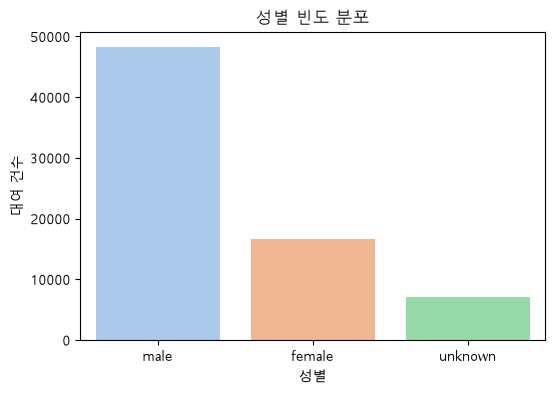

In [25]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='gender', palette='pastel')
plt.title('성별 빈도 분포')
plt.xlabel('성별')
plt.ylabel('대여 건수')
plt.show()

### 해석 - gender
압도적인 남성 비율: 남성 이용자가 여성보다 약 3배가량 많습니다. 뉴욕 도심의 도로 여건이나 자전거 안전에 대한 심리적 허들이 성별에 따라 다르게 작용하고 있을 수 있습니다.

Unknown 변수의 의미: 성별 미상 비율이 약 9.5%나 됩니다. 이는 단순한 기입 누락이 아니라 특정 사용자 그룹(비회원 등)의 특성일 수 있으니 후속 분석이 필요해 보입니다.

### 3 이진 변수 분석

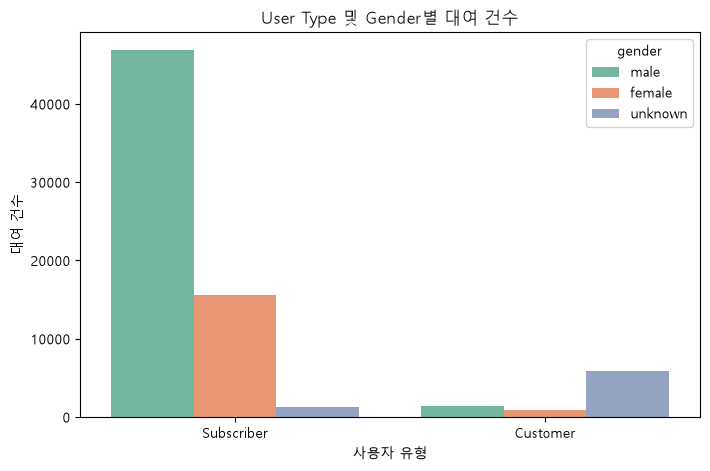

In [26]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='usertype', hue='gender', palette='Set2')
plt.title('User Type 및 Gender별 대여 건수')
plt.xlabel('사용자 유형')
plt.ylabel('대여 건수')
plt.show()

### usertype × gender 
구독자와 일시 이용자의 차이: 정기 구독자는 98%가 성별이 파악되지만, 일시 이용자는 70% 이상이 성별 미상입니다.

원인 분석: 일시 이용자는 회원가입을 하며 개인정보를 입력할 필요 없이, 길거리 키오스크에서 현장 결제만 하고 바로 자전거를 탑승하기 때문에 정보가 누락된 것입니다. 'Unknown' 변수일 것으로 추측됩니다.

### #4 다변수 분석

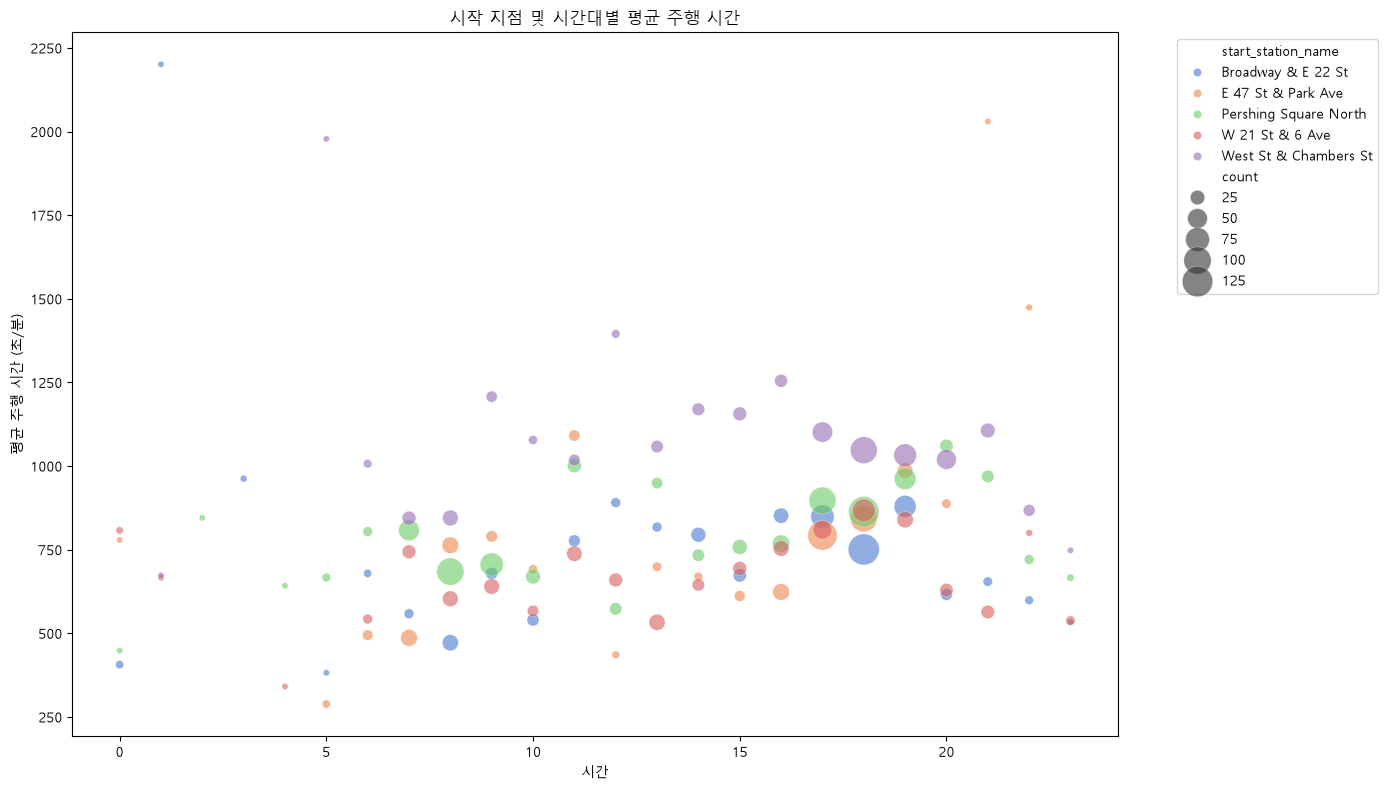

In [27]:
summary_df = df_filtered.groupby(['start_station_name', 'start_hour']).agg(
    avg_duration=('trip_duration', 'mean'),
    count=('trip_duration', 'count')
).reset_index()

top_stations = df_filtered['start_station_name'].value_counts().head(5).index
bubble_data = summary_df[summary_df['start_station_name'].isin(top_stations)]

plt.figure(figsize=(14, 8))
sns.scatterplot(
    data=bubble_data, 
    x='start_hour', 
    y='avg_duration', 
    size='count', 
    sizes=(20, 500), 
    hue='start_station_name', 
    alpha=0.6,
    palette='muted'
)
plt.title('시작 지점 및 시간대별 평균 주행 시간')
plt.xlabel('시간')
plt.ylabel('평균 주행 시간 (초/분)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

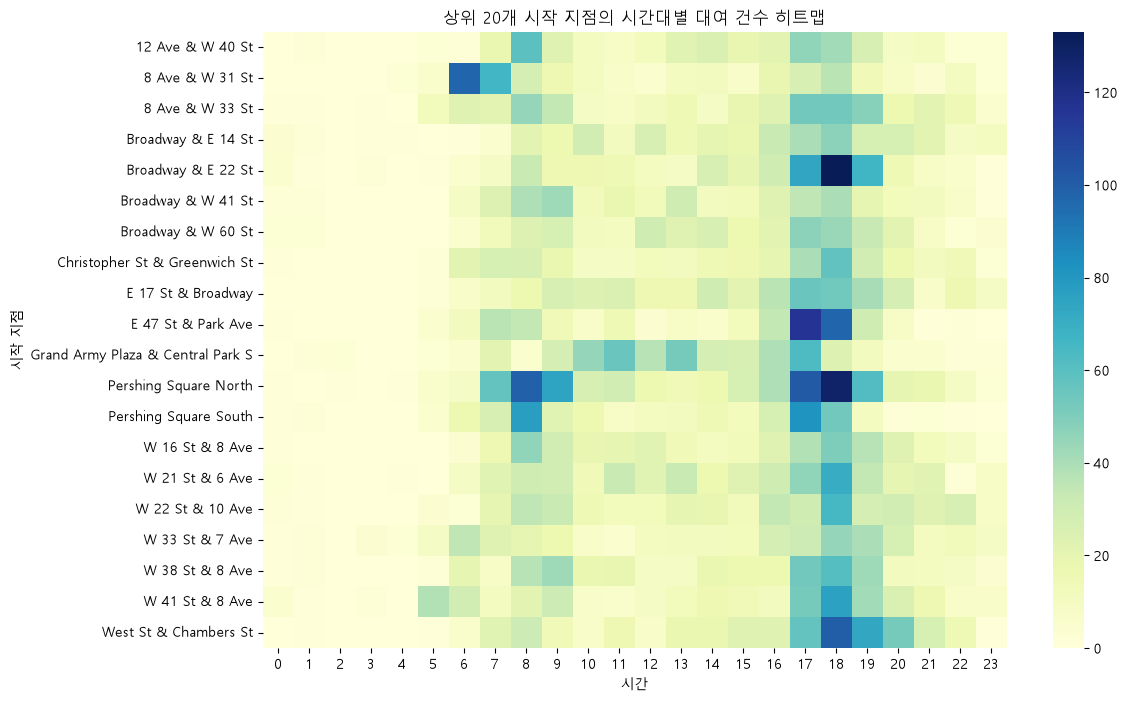

In [28]:
top_20_stations = df['start_station_name'].value_counts().head(20).index
heatmap_data = df[df['start_station_name'].isin(top_20_stations)]

pivot_table = heatmap_data.pivot_table(
    index='start_station_name', 
    columns='start_hour', 
    values='trip_duration', 
    aggfunc='count', 
    fill_value=0
)

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_table, cmap='YlGnBu', annot=False)
plt.title('상위 20개 시작 지점의 시간대별 대여 건수 히트맵')
plt.xlabel('시간')
plt.ylabel('시작 지점')
plt.show()

### 해석 - 다변수 분석 
교통 허브의 출퇴근 러시: 'Pershing Square North' 같은 거대 기차역 앞 대여소는 아침 8시와 저녁 6시에 대여량이 폭발적으로 치솟습니다. 통근자들이 자전거를 타고 출근하는 아침 풍경을 짐작할 수 있습니다.

관광 및 레저 장소: 허드슨 강변('West St & Chambers St') 같은 곳은 출퇴근 시간에 뾰족하게 몰리기보다는 낮 시간대 전반에 걸쳐 고르게 대여가 일어납니다. 뷰를 즐기며 여유롭게 산책하는 관광객들의 핫스팟임을 알 수 있습니다.